<img src="https://i.ibb.co/6fXxh1Y/genial-logo-banner-dark.png" style="width:100%; height:auto;">

# **Aula 4 - Otimização por Enxame de Partículas (PSO)**

Seja bem vindo(a) ao curso **Genetic and Evolutionary Nature-Inspired ALgorithms (GENIAL)**.

Nesta quarta aula, vamos explorar a fundo o algoritmo de Otimização por Enxame de Partículas, conceituar os seus componentes básicos, descrever o seu processo iterativo e codificar um exemplo prático de PSO para testar o seu desempenho em benchmarks.

In [1]:
import math
import random

import pandas as pd
from IPython.display import HTML

from pso_utils.animar_espaco_de_busca import animar_espaco_de_busca
from pso_utils.animar_pso_2d import animar_pso_2d
from pso_utils.animar_pso_3d import animar_pso_3d
from pso_utils.plotar_benchmark import plotar_benchmark
from pso_utils.gerar_animacoes import gerar_animacao
from pso_utils.obter_particulas_dataframe import obter_particulas_dataframe
from pso_utils.plotar_espaco_de_busca import plotar_espaco_de_busca
from pso_utils.pso import PSO

In [2]:
random.seed(42)

## 4.1 Introdução

A **Otimização por Enxame de Partículas (PSO)** é uma técnica de busca e otimização inspirada no comportamento coletivo observado em bandos de pássaros e cardumes de peixes. Proposto por **Kennedy e Eberhart (1995)**, o método pertence à classe dos **algoritmos de inteligência de enxame (Swarm Intelligence)** e destaca-se pela simplicidade de implementação e boa eficiência na exploração de espaços contínuos de solução.

<a href="https://imgbb.com/"><img src="https://media.licdn.com/dms/image/v2/C5603AQFR407TdIUoVA/profile-displayphoto-shrink_800_800/profile-displayphoto-shrink_800_800/0/1516798504680?e=1763596800&v=beta&t=6pEMeFdVgzuKchnAjLyNdv8tJYF-PvLGj5Ve3mi_LUE" alt="1516798504680" border="0"></a>
<a href="https://imgbb.com/"><img src="https://media.licdn.com/dms/image/v2/C4E03AQH1HdcfbTFIfA/profile-displayphoto-shrink_800_800/profile-displayphoto-shrink_800_800/0/1516584392486?e=1763596800&v=beta&t=C9bQLxc1WqBrkrWCFDrW0-H0_CEhAdGYU45vc69yVQ0" alt="1516798504680" border="0"></a>

Assim como outros algoritmos baseados em comportamento coletivo, o PSO utiliza princípios de cooperação e auto-organização. Seu funcionamento pode ser compreendido a partir de uma analogia com a busca de alimento realizada por um bando de pássaros. Imagine um grupo de pássaros procurando alimento em uma grande região desconhecida. Inicialmente, nenhum deles sabe onde está a melhor fonte de comida. Cada pássaro explora uma direção diferente do espaço e, durante o processo, armazena duas informações fundamentais:

- **Experiência individual**: cada pássaro memoriza o melhor ponto que encontrou ao longo do caminho (melhor posição pessoal).
- **Experiência coletiva**: os pássaros também observam uns aos outros e identificam qual membro do grupo já esteve na melhor região encontrada até o momento (melhor posição global).

Com base nessas duas referências, cada pássaro ajusta sua trajetória ao longo do tempo. Esse ajuste cria um equilíbrio entre:

- **_Exploration_**: busca por novas regiões do espaço de soluções.
- **_Exploitation_**: intensificação na busca ao redor das melhores regiões já conhecidas.

À medida que interagem e compartilham informações, os pássaros passam a concentrar sua busca em áreas mais promissoras do espaço. Esse comportamento coletivo faz com que o grupo convirja gradualmente em direção à melhor solução do problema.

<a href="https://ibb.co/BKvd024v"><img src="https://i.ibb.co/n84ZxM34/Screenshot-from-2025-10-30-13-23-53.png" alt="Screenshot-from-2025-10-30-13-23-53" border="0"></a>

<a href="https://ibb.co/4wmTd8zJ"><img src="https://i.ibb.co/kVH814jM/Screenshot-from-2025-10-30-13-24-17.png" alt="Screenshot-from-2025-10-30-13-24-17" border="0"></a>

<a href="https://ibb.co/C56G9G9t"><img src="https://i.ibb.co/xSYTgTgs/Screenshot-from-2025-10-30-13-24-34.png" alt="Screenshot-from-2025-10-30-13-24-34" border="0"></a>

O PSO tem sido amplamente aplicado em:

- Otimização contínua e não linear
- Ajuste de parâmetros e calibração de modelos de inteligência artifical
- Engenharia, controle e processamento de sinais

<img src= "https://computacaointeligente.com.br/assets/img/posts/pso/pso-birds.png" alt="pso-birds" style="width:70%; height:auto;">

## 4.2 Estrutura do PSO

Para compreender a estrutura básica do PSO, vamos analisar o **problema de minimização da função** $f(x) = \sin(3x) + \frac{x^2}{7}$. Nesse problema, o objetivo é encontrar o valor de $x$ que torna a função o menor possível. Geometricamente, trata-se de encontrar o ponto mais baixo da curva, cujo **mínimo global** está localizado em $x = -0.50748$. Nesse problema, o PSO simula o movimento de diversas partículas ao longo do eixo real. Cada partícula representa uma possível solução e se desloca pelo espaço de busca em direção a regiões com valores menores da função.

### 4.2.1 Representação do Problema

No PSO, o problema de otimização não é representado como um grafo, mas como um **espaço de busca**. No exemplo considerado, o espaço de busca é **unidimensional**, pois estamos procurando o valor de uma única variável $x$ que minimize a função $f$. Para controlar onde as partículas podem se mover, definimos um **intervalo de busca**. Por exemplo: $x \in [-5, 5].$ Esse intervalo representa todas as possíveis soluções do problema. A busca pelo mínimo global será realizada dentro desse intervalo.

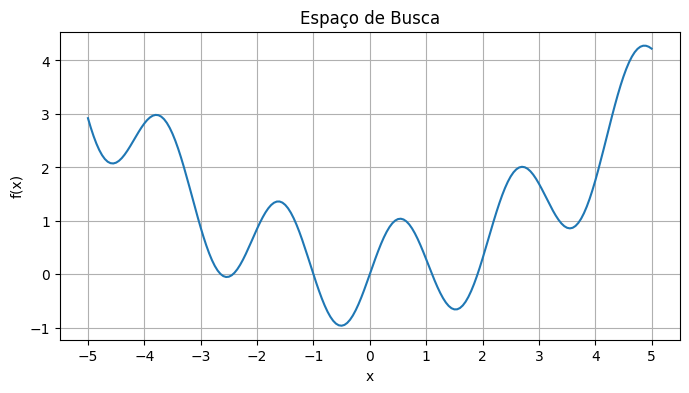

In [3]:
plotar_espaco_de_busca()

### 4.2.2 Partículas

No PSO, as **partículas** são os agentes que exploram o espaço de busca em busca de soluções. Cada partícula representa uma possível solução do problema e possui duas características principais: **posição** e **velocidade**.

- A **posição** representa o valor atual que a partícula está testando como solução.
- A **velocidade** determina como a posição será atualizada a cada iteração, controlando o movimento da partícula no espaço de busca.

<img src= "https://i.ibb.co/RTjkWK5B/visual-selection-13.png" alt="pso-birds" style="width:35%; height:auto;">

No estágio inicial, as partículas são distribuídas **aleatoriamente** dentro do intervalo de busca definido. Cada partícula avalia sua posição usando a função objetivo e armazena seu desempenho para uso posterior no processo de otimização.

In [4]:
n_particulas = 5
limite_inferior = -5
limite_superior = 5

particulas = []
for _ in range(n_particulas):
    posicao = random.uniform(limite_inferior, limite_superior)
    velocidade = random.uniform(-1, 1)
    particulas.append({
        "Posição": posicao,
        "Velocidade": velocidade,
    })

df_particulas = obter_particulas_dataframe(particulas)
display(df_particulas)

,Posição,Velocidade
Partícula 1,1.394268,-0.949978
Partícula 2,-2.249707,-0.553579
Partícula 3,2.364712,0.353399
Partícula 4,3.921796,-0.826122
Partícula 5,-0.780782,-0.940406


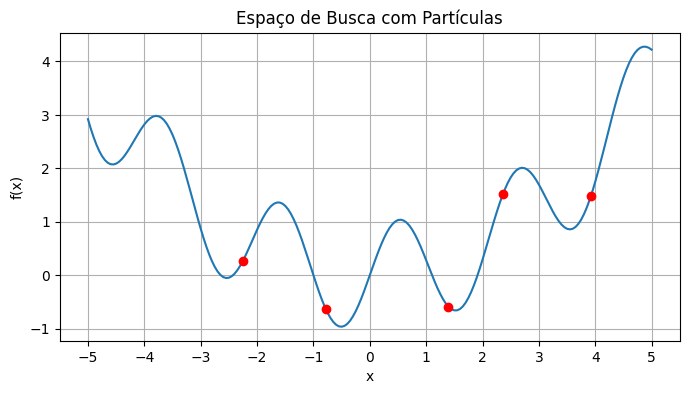

In [5]:
plotar_espaco_de_busca(particulas)

### 4.2.3 Função Objetivo

A **função objetivo** é responsável por avaliar a qualidade de cada solução gerada pelo algoritmo. No contexto do PSO, cada partícula representa uma posição no espaço de busca, e a função objetivo calcula o valor dessa posição. Como estamos tratando de um problema de **minimização**, quanto menor o valor da função, melhor é a solução. No exemplo utilizado, a função objetivo é $f(x) = \sin(3x) + \frac{x^2}{7}$.

In [6]:
def f(x):
    return math.sin(3 * x) + (x ** 2) / 7

for p in particulas:
    p["f(x)"] = p["Posição"]

df_particulas = obter_particulas_dataframe(particulas)
display(df_particulas)

,Posição,Velocidade,f(x)
Partícula 1,1.394268,-0.949978,1.394268
Partícula 2,-2.249707,-0.553579,-2.249707
Partícula 3,2.364712,0.353399,2.364712
Partícula 4,3.921796,-0.826122,3.921796
Partícula 5,-0.780782,-0.940406,-0.780782


### 4.2.4 Memória Individual e Global

No PSO, o compartilhamento de informações acontece por meio de **memória**. Cada partícula armazena duas informações importantes:

- **Melhor posição pessoal ($p_{best}$):** é a melhor posição que a **própria partícula** encontrou até o momento.
- **Melhor posição global ($g_{best}$):** é a melhor posição encontrada por **qualquer** partícula do enxame.

Esses valores guiam o movimento das partículas, que ajustam suas velocidades considerando tanto o que aprenderam individualmente quanto o que foi descoberto coletivamente. Inicialmente, como nenhuma partícula possui histórico, o valor de $p_{best}$ de cada partícula é inicialmente sua posição atual, e o $g_{best}$ é definido como a melhor posição entre todos os $p_{best}$ iniciais.


In [7]:
for p in particulas:
    p["pbest"] = p["Posição"]
    p["f(pbest)"] = f(p["Posição"])

gbest = min(particulas, key=lambda p: p["f(pbest)"])

df_particulas = obter_particulas_dataframe(particulas)
display(df_particulas)
print(f"gbest: x = {gbest['pbest']}, f(x) = {gbest['f(pbest)']}")

,Posição,Velocidade,f(x),pbest,f(pbest)
Partícula 1,1.394268,-0.949978,1.394268,1.394268,-0.585305
Partícula 2,-2.249707,-0.553579,-2.249707,-2.249707,0.273767
Partícula 3,2.364712,0.353399,2.364712,2.364712,1.523780
Partícula 4,3.921796,-0.826122,3.921796,3.921796,1.479171
Partícula 5,-0.780782,-0.940406,-0.780782,-0.780782,-0.629743


gbest: x = -0.7807818031472955, f(x) = -0.6297428342080246


## 4.3 Etapas

### 4.3.1 Inicialização

Nesta etapa, os parâmetros do algoritmo e as variáveis principais são definidos. Isso inclui:

- **Número de partículas** no enxame.
- **Número máximo de iterações** do algoritmo.
- **Espaço de busca** onde as partículas podem se mover.
- **Função objetivo**.
- **Parâmetros de controle** (coeficiente de inércia, componente cognitivo e componente social).
- **Posições e velocidades iniciais** das partículas.
- **Memórias individual e global**.

In [8]:
def f(x):
    return math.sin(3 * x) + (x ** 2) / 7

n_particulas = 10
n_iteracoes = 50
limite_inferior = -5
limite_superior = 5
w = 0.7
c1 = 1.5
c2 = 1.5

particulas = []
for _ in range(n_particulas):
    posicao = random.uniform(limite_inferior, limite_superior)
    velocidade = random.uniform(-1, 1)
    particulas.append({
        "Posição": posicao,
        "Velocidade": velocidade,
        "f(x)": f(posicao),
        "pbest": posicao,
        "f(pbest)": f(posicao),
    })

gbest = min(particulas, key=lambda p: p["f(pbest)"])

df_particulas = obter_particulas_dataframe(particulas)
display(df_particulas)
print(f"gbest: x = {gbest['pbest']}, f(x) = {gbest['f(pbest)']}")

,Posição,Velocidade,f(x),pbest,f(pbest)
Partícula 1,-2.813620,0.010711,0.298250,-2.813620,0.298250
Partícula 2,-4.734640,-0.602325,2.204630,-4.734640,2.204630
Partícula 3,1.498844,0.089883,-0.655860,1.498844,-0.655860
Partícula 4,-2.795594,0.178531,0.255089,-2.795594,0.255089
Partícula 5,3.094305,-0.987002,1.509206,3.094305,1.509206
Partícula 6,3.058193,0.396279,1.583675,3.058193,1.583675
Partícula 7,-1.597495,-0.689041,1.361364,-1.597495,1.361364
Partícula 8,4.572131,-0.326811,3.899113,4.572131,3.899113
Partícula 9,-4.072542,-0.806567,2.711090,-4.072542,2.711090
Partícula 10,3.474944,0.207452,0.883534,3.474944,0.883534


gbest: x = 1.4988443777952316, f(x) = -0.655859948118207


### 4.3.3 Atualização das Velocidades

Após avaliar as partículas, o próximo passo do PSO é **atualizar a velocidade** de cada uma delas. A velocidade determina a direção e a intensidade do movimento da partícula no espaço de busca. A atualização da velocidade é guiada por três componentes:

- **Inércia ($w$):** mantém parte do movimento anterior, incentivando a exploração contínua.
<a href="https://ibb.co/BHdwSJvw"><img src="https://i.ibb.co/GfBFbDGF/Screenshot-from-2025-10-30-15-07-09.png" alt="Screenshot-from-2025-10-30-15-07-09" border="0"></a>

<img 
src="https://i.ibb.co/bR3ZyWzp/compara-o-sem-e-com-inercia.png" alt="compara-o-sem-e-com-inercia" width="1080"></img>




- **Componente cognitivo ($c_1$):** representa o aprendizado individual da partícula, atraindo-a para sua melhor posição pessoal ($p_{best}$).
- **Componente social ($c_2$):** representa o aprendizado coletivo, atraindo a partícula para a melhor posição global ($g_{best}$).

A equação de atualização da velocidade é dada por:

$$
v_i = w \cdot v_i + c_1 \cdot r_1 \cdot (pbest_i - x_i) + c_2 \cdot r_2 \cdot (gbest - x_i)
$$

onde $v_i$ é a velocidade da partícula $i$, $x_i$ é a posição atual da partícula, $r_1$ e $r_2$ são números aleatórios em $[0, 1]$.


In [9]:
def atualizar_velocidades(particulas, gbest, w, c1, c2):
    for p in particulas:
        r1 = random.random()
        r2 = random.random()

        nova_velocidade = (
            w * p["Velocidade"]
            + c1 * r1 * (p["pbest"] - p["Posição"])
            + c2 * r2 * (gbest["pbest"] - p["Posição"])
        )

        p["Velocidade"] = nova_velocidade

print("Partículas antes da atualização de velocidades:")
df_particulas = obter_particulas_dataframe(particulas)
display(df_particulas)

atualizar_velocidades(particulas, gbest, w, c1, c2)

print("Partículas após atualização de velocidades:")
df_particulas = obter_particulas_dataframe(particulas)
display(df_particulas)

Partículas antes da atualização de velocidades:


,Posição,Velocidade,f(x),pbest,f(pbest)
Partícula 1,-2.813620,0.010711,0.298250,-2.813620,0.298250
Partícula 2,-4.734640,-0.602325,2.204630,-4.734640,2.204630
Partícula 3,1.498844,0.089883,-0.655860,1.498844,-0.655860
Partícula 4,-2.795594,0.178531,0.255089,-2.795594,0.255089
Partícula 5,3.094305,-0.987002,1.509206,3.094305,1.509206
Partícula 6,3.058193,0.396279,1.583675,3.058193,1.583675
Partícula 7,-1.597495,-0.689041,1.361364,-1.597495,1.361364
Partícula 8,4.572131,-0.326811,3.899113,4.572131,3.899113
Partícula 9,-4.072542,-0.806567,2.711090,-4.072542,2.711090
Partícula 10,3.474944,0.207452,0.883534,3.474944,0.883534


Partículas após atualização de velocidades:


,Posição,Velocidade,f(x),pbest,f(pbest)
Partícula 1,-2.813620,4.727911,0.298250,-2.813620,0.298250
Partícula 2,-4.734640,8.677226,2.204630,-4.734640,2.204630
Partícula 3,1.498844,0.062918,-0.655860,1.498844,-0.655860
Partícula 4,-2.795594,4.109264,0.255089,-2.795594,0.255089
Partícula 5,3.094305,-2.072615,1.509206,3.094305,1.509206
Partícula 6,3.058193,0.170211,1.583675,3.058193,1.583675
Partícula 7,-1.597495,0.861736,1.361364,-1.597495,1.361364
Partícula 8,4.572131,-1.301917,3.899113,4.572131,3.899113
Partícula 9,-4.072542,1.758450,2.711090,-4.072542,2.711090
Partícula 10,3.474944,-0.936200,0.883534,3.474944,0.883534


### 4.3.4 Atualização das Posições

Após atualizar as velocidades, cada partícula ajusta sua posição no espaço de busca. O movimento de cada partícula é determinado pela equação:

$$
x_i = x_i + v_i
$$

onde $x_i$ é a posição atual da partícula e $v_i$ é sua nova velocidade.

É importante garantir que as partículas permaneçam dentro do **intervalo de busca permitido**. Caso ultrapassem os limites, podemos:

- **Conter a posição** no limite mais próximo
- **Reiniciar a partícula** dentro do intervalo

Aqui utilizaremos a estratégia de contenção, mantendo as partículas dentro do espaço de busca.

In [10]:
def atualizar_posicoes(particulas, limite_inferior, limite_superior):
    for p in particulas:
        nova_posicao = p["Posição"] + p["Velocidade"]

        if nova_posicao < limite_inferior:
            nova_posicao = limite_inferior
        elif nova_posicao > limite_superior:
            nova_posicao = limite_superior

        p["Posição"] = nova_posicao

Partículas antes da atualização de posições:


,Posição,Velocidade,f(x),pbest,f(pbest)
Partícula 1,-2.813620,4.727911,0.298250,-2.813620,0.298250
Partícula 2,-4.734640,8.677226,2.204630,-4.734640,2.204630
Partícula 3,1.498844,0.062918,-0.655860,1.498844,-0.655860
Partícula 4,-2.795594,4.109264,0.255089,-2.795594,0.255089
Partícula 5,3.094305,-2.072615,1.509206,3.094305,1.509206
Partícula 6,3.058193,0.170211,1.583675,3.058193,1.583675
Partícula 7,-1.597495,0.861736,1.361364,-1.597495,1.361364
Partícula 8,4.572131,-1.301917,3.899113,4.572131,3.899113
Partícula 9,-4.072542,1.758450,2.711090,-4.072542,2.711090
Partícula 10,3.474944,-0.936200,0.883534,3.474944,0.883534


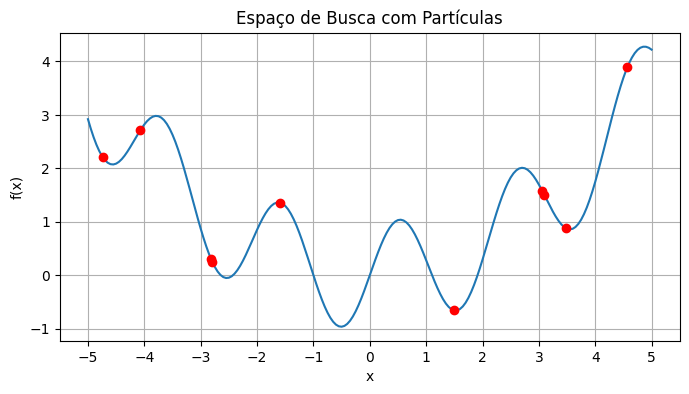

In [11]:
print("Partículas antes da atualização de posições:")
df_particulas = obter_particulas_dataframe(particulas)
display(df_particulas)
plotar_espaco_de_busca(particulas)

In [12]:
atualizar_posicoes(particulas, limite_inferior, limite_superior)

Partículas após atualização de posições:


,Posição,Velocidade,f(x),pbest,f(pbest)
Partícula 1,1.914291,4.727911,0.298250,-2.813620,0.298250
Partícula 2,3.942586,8.677226,2.204630,-4.734640,2.204630
Partícula 3,1.561762,0.062918,-0.655860,1.498844,-0.655860
Partícula 4,1.313670,4.109264,0.255089,-2.795594,0.255089
Partícula 5,1.021689,-2.072615,1.509206,3.094305,1.509206
Partícula 6,3.228403,0.170211,1.583675,3.058193,1.583675
Partícula 7,-0.735759,0.861736,1.361364,-1.597495,1.361364
Partícula 8,3.270214,-1.301917,3.899113,4.572131,3.899113
Partícula 9,-2.314091,1.758450,2.711090,-4.072542,2.711090
Partícula 10,2.538743,-0.936200,0.883534,3.474944,0.883534


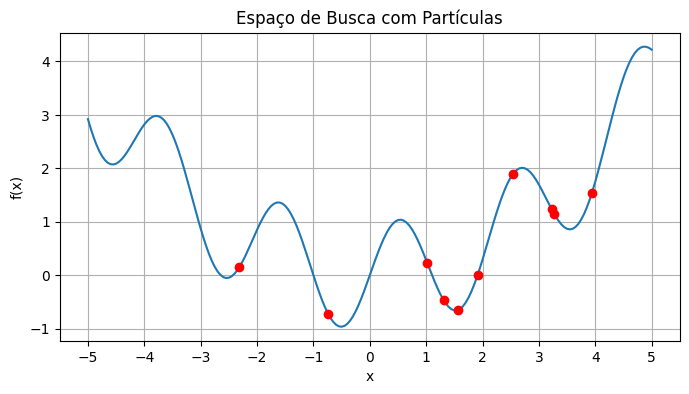

In [13]:
print("Partículas após atualização de posições:")
df_particulas = obter_particulas_dataframe(particulas)
display(df_particulas)
plotar_espaco_de_busca(particulas)

### 4.3.2 Avaliação das Soluções e Atualização

Após a atualização da velocidade e posição, cada partícula avalia sua posição atual por meio da **função objetivo**. O valor retornado pela função objetivo indica a **qualidade da solução** representada pela partícula. Como este é um problema de **minimização**, quanto menor o valor de $f(x)$, melhor é a solução. Após calcular $f(x)$ para cada partícula:

- Se a nova posição for melhor do que a sua melhor posição anterior, então o $p_{best}$ é atualizado.
- Se alguma partícula encontrar uma solução melhor que a melhor solução global atual, então o $g_{best}$ é atualizado.

In [14]:
def atualizar_memoria(particulas, funcao_objetivo):
    global gbest

    for p in particulas:
        valor_atual = funcao_objetivo(p["Posição"])

        if valor_atual < p["f(pbest)"]:
            p["pbest"] = p["Posição"]
            p["f(pbest)"] = valor_atual

    gbest = min(particulas, key=lambda p: p["f(pbest)"])

df_particulas = obter_particulas_dataframe(particulas)
display(df_particulas)
print(f"gbest: x = {gbest['pbest']}, f(x) = {gbest['f(pbest)']}")

,Posição,Velocidade,f(x),pbest,f(pbest)
Partícula 1,1.914291,4.727911,0.298250,-2.813620,0.298250
Partícula 2,3.942586,8.677226,2.204630,-4.734640,2.204630
Partícula 3,1.561762,0.062918,-0.655860,1.498844,-0.655860
Partícula 4,1.313670,4.109264,0.255089,-2.795594,0.255089
Partícula 5,1.021689,-2.072615,1.509206,3.094305,1.509206
Partícula 6,3.228403,0.170211,1.583675,3.058193,1.583675
Partícula 7,-0.735759,0.861736,1.361364,-1.597495,1.361364
Partícula 8,3.270214,-1.301917,3.899113,4.572131,3.899113
Partícula 9,-2.314091,1.758450,2.711090,-4.072542,2.711090
Partícula 10,2.538743,-0.936200,0.883534,3.474944,0.883534


gbest: x = 1.4988443777952316, f(x) = -0.655859948118207


### 4.3.5 Iteração

As etapas anteriores (avaliação, atualização da velocidade e atualização da posição) são repetidas ao longo de várias **iterações** até que um **critério de parada** seja satisfeito, como:
- Alcançar o número máximo de iterações.
- Encontrar uma solução aceitável com erro mínimo.
- Ausência de melhoria em $g_{best}$ por várias iterações.


In [15]:
log_gbest = []
log_particulas = []

for _ in range(n_iteracoes):
    atualizar_velocidades(particulas, gbest, w, c1, c2)
    atualizar_posicoes(particulas, limite_inferior, limite_superior)
    atualizar_memoria(particulas, f)

    log_gbest.append({
        "gbest": gbest["pbest"],
        "f(x)": gbest["f(pbest)"],
    })
    posicao_particula = [{"Posição": p["Posição"], "f(gbest)": gbest["f(pbest)"]} for p in particulas]
    log_particulas.append(posicao_particula)

df_gbest = pd.DataFrame(log_gbest)
df_gbest.index = [f"Iteração {i + 1}" for i in range(len(log_gbest))]
display(df_gbest)

,gbest,f(x)
Iteração 1,1.498844,-0.655860
Iteração 2,1.498844,-0.655860
Iteração 3,-0.458559,-0.950985
Iteração 4,-0.458559,-0.950985
Iteração 5,-0.458559,-0.950985
Iteração 6,-0.458559,-0.950985
Iteração 7,-0.473890,-0.956819
Iteração 8,-0.502974,-0.961946
Iteração 9,-0.502974,-0.961946
Iteração 10,-0.502974,-0.961946


In [16]:
animacao = animar_espaco_de_busca(log_particulas)
HTML(animacao.to_html5_video())

RuntimeError: Requested MovieWriter (ffmpeg) not available

## 4.4 Definição Formal

Seja $f: S \subseteq \mathbb{R}^d \to \mathbb{R}$ a função objetivo, com $d \in \mathbb{N}^+$, onde $S$ representa o espaço de busca $d$-dimensional. O problema de otimização pode ser definido como:

$$
\min_{x \in S} f(x).
$$

O enxame é composto por $n$ partículas. Cada partícula $i \in [1, n]$ no instante de tempo $t \in \mathbb{N}$ possui:  
- posição $x_i^t \in \mathbb{R}^d$,  
- velocidade $v_i^t \in \mathbb{R}^d$,  
- melhor posição pessoal $p_i^t \in \mathbb{R}^d$,  
- melhor posição global** do enxame $g^t \in \mathbb{R}^d$.  

---

Em cada iteração $t$, a velocidade e a posição são atualizadas pelas equações:

$$
v_i^{t+1} = w v_i^t + c_1 r_{1,i}^t (p_i^t - x_i^t) + c_2 r_{2,i}^t (g^t - x_i^t),
$$  

onde:  
- $w > 0$ é o peso de inércia,  
- $c_1, c_2 > 0$ são os coeficientes cognitivo e social,  
- $r_{1,i}^t, r_{2,i}^t \sim U(0, 1)$ são números aleatórios uniformemente distribuídos no intervalo $[0,1]$.  

A posição é atualizada como:

$$
x_i^{t+1} = x_i^t + v_i^{t+1}.
$$

---

A atualização do melhor pessoal e do melhor global ocorre da seguinte forma:

$$
p_i^{t+1} =
\begin{cases}
x_i^{t+1}, & \text{se } f(x_i^{t+1}) < f(p_i^t), \\
p_i^t, & \text{caso contrário},
\end{cases}
$$

$$
g^{t+1} =
\begin{cases}
x_i^{t+1}, & \text{se } f(x_i^{t+1}) < f(g^t), \\
g^t, & \text{caso contrário}.
\end{cases}
$$

---

Assim, o algoritmo é iterativo: a cada passo, as partículas movem-se pelo espaço de busca influenciadas pela inércia do movimento anterior, pela melhor solução individual e pela melhor solução coletiva. Esse processo é repetido até o critério de parada ser atingido (número máximo de iterações, convergência do enxame ou tempo limite).  


## 4.5 Exemplo

### 4.5.1 Funções de Benchmark

**Funções de benchmark** são funções matemáticas padronizadas utilizadas para **avaliar e comparar algoritmos de otimização**. Elas são construídas de forma proposital para representar diferentes desafios encontrados em problemas reais:

- Superfícies com muitos mínimos locais para testar a exploração do algoritmo.
- Áreas planas ou enganosas que exigem equilíbrio entre exploração e intensificação.
- Dimensionalidade variável para analisar se o desempenho é escalável.
- Complexidade multimodal para avaliar a habilidade de escapar de ótimos locais.

Essas funções possuem mínimo global conhecido, o que permite medir objetivamente se o algoritmo está convergindo para a solução correta. Em outras palavras: benchmarks são como pistas de corrida padronizadas onde testamos, avaliando sua **eficiência, robustez e velocidade de convergência**.

### 4.5.2 Função Schaffer

$$
f(x, y) = 0.5 + \frac{ \sin^2(x^2 - y^2) - 0.5 }{ [1 + 0.001(x^2 + y^2)]^2 }
$$

- **Dimensões:** 2  
- **Espaço de busca:** $x, y \in [-100, 100]$  
- **Mínimo global:** $f(0, 0) = 0$

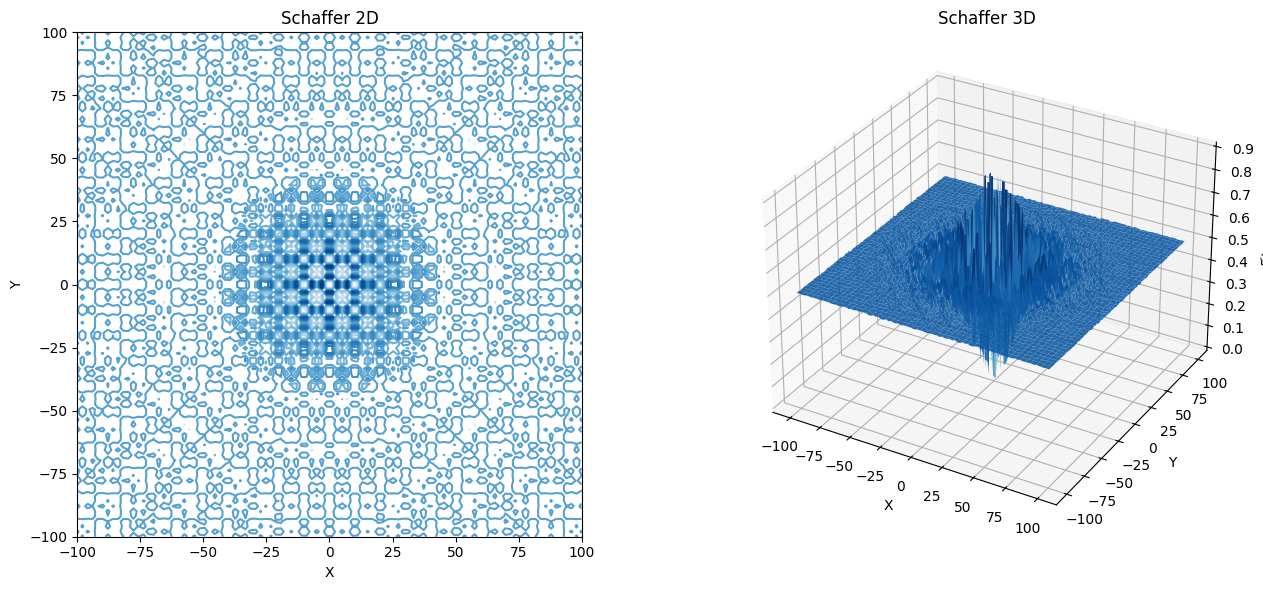

In [ ]:
plotar_benchmark("schaffer")

In [ ]:
def schaffer(x):
    total = 0.0
    for i in range(len(x) - 1):
        num = math.sin(x[i]**2 - x[i+1]**2)**2 - 0.5
        den = (1 + 0.001 * (x[i]**2 + x[i+1]**2))**2
        total += 0.5 + num / den
    return total

limites_schaffer = (-100, 100)

### 4.5.3 Função Griewank

$$
f(\mathbf{x}) = 1 + \sum_{i=1}^{n} \frac{x_i^2}{4000} - \prod_{i=1}^{n} \cos\left(\frac{x_i}{\sqrt{i}}\right)
$$

- **Dimensões:** $n$ 
- **Espaço de busca:** $x_i \in [-600, 600]$  
- **Mínimo global:** $f(\mathbf{0}) = 0$

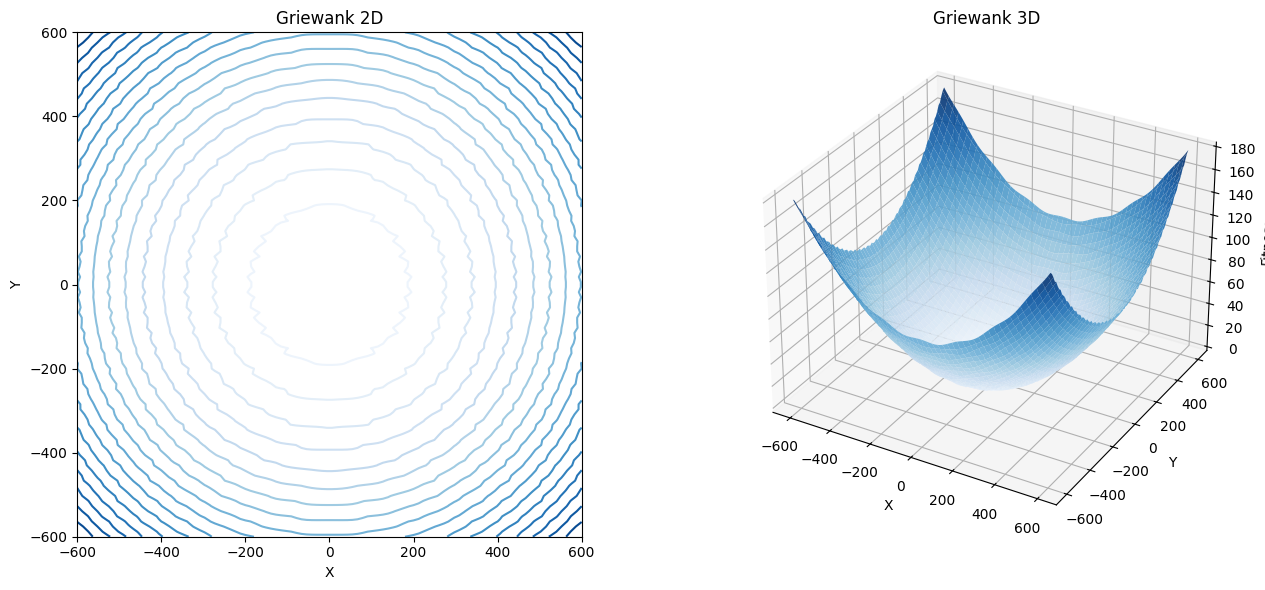

In [ ]:
plotar_benchmark("griewank")

In [ ]:
def griewank(x):
    sum_part = sum(xi**2 for xi in x) / 4000.0
    prod_part = 1.0
    for i, xi in enumerate(x, start=1):
        prod_part *= math.cos(xi / math.sqrt(i))
    return 1 + sum_part - prod_part

limites_griewank = (-600, 600)

### 4.5.4 Função Ackley

$$
f(\mathbf{x}) = -20 \exp\left( -0.2\sqrt{\frac{1}{n}\sum_{i=1}^{n} x_i^2} \right)
- \exp\left( \frac{1}{n}\sum_{i=1}^{n} \cos(2\pi x_i) \right)
+ 20 + e
$$

- **Dimensões:** $n$  
- **Espaço de busca:** $x_i \in [-32.768, 32.768]$  
- **Mínimo global:** $f(\mathbf{0}) = 0$

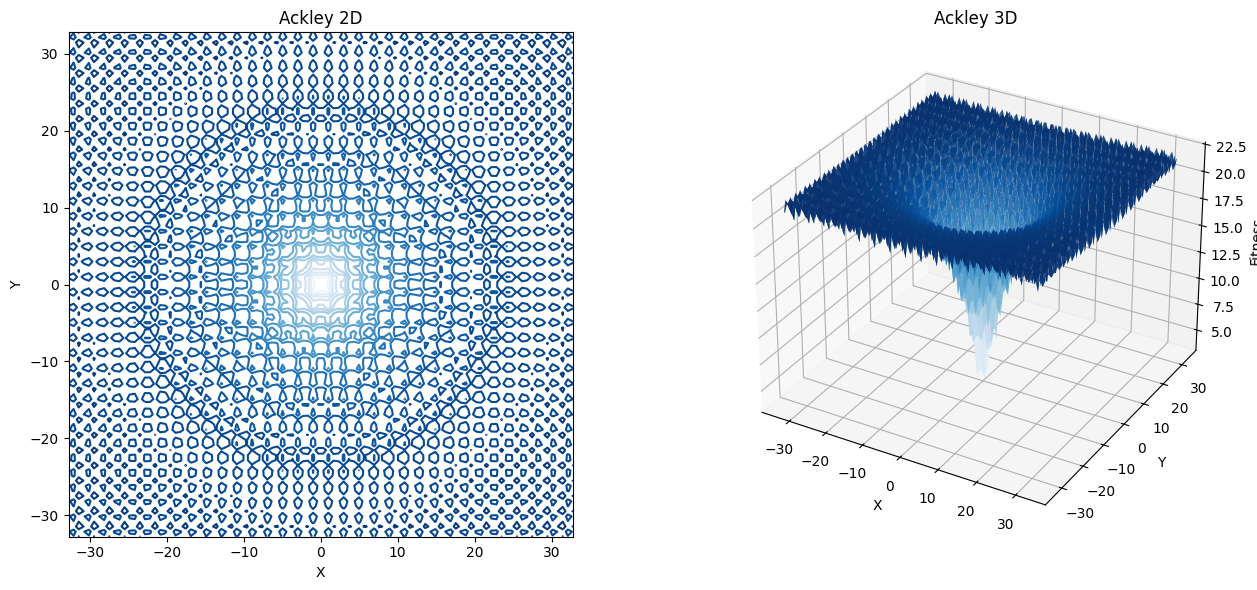

In [ ]:
plotar_benchmark("ackley")

In [ ]:
def ackley(x):
    n = len(x)
    sum_sq = sum(xi**2 for xi in x)
    sum_cos = sum(math.cos(2 * math.pi * xi) for xi in x)

    term1 = -20 * math.exp(-0.2 * math.sqrt(sum_sq / n))
    term2 = -math.exp(sum_cos / n)
    return term1 + term2 + 20 + math.e

limites_ackley = (-32.768, 32.768)

### 4.5.5 Definição dos Parâmetros e Hiperparâmetros

In [ ]:
N_PARTICULAS = 20
N_ITERACOES = 20
DIMENSAO = 2
INERCIA = 0.5
COGNITIVO = 1.5
SOCIAL = 1.5

### 4.5.6 Resultados

In [ ]:
benchmark = [
    ("schaffer", schaffer, limites_schaffer),
    ("griewank", griewank, limites_griewank),
    ("ackley", ackley, limites_ackley),
]

In [ ]:
animacoes_2d = []
animacoes_3d = []

for i, (nome, funcao, limites) in enumerate(benchmark, start=1):
    print("\n" + "-" * 90)
    print(f"[{i}] Função de Benchmark: {nome.upper()}")

    posicoes_iniciais = [
        [random.uniform(*limites) for _ in range(DIMENSAO)]
        for _ in range(N_PARTICULAS)
    ]

    pso = PSO(
        posicoes=posicoes_iniciais,
        funcao_objetivo=funcao,
        n_iteracoes=N_ITERACOES,
    )
    posicao_gbest, gbest = pso.otimizar(INERCIA, COGNITIVO, SOCIAL)

    print(f"> Melhor posição encontrada: {posicao_gbest}")
    print(f"> Melhor Fitness: {gbest}")

    ani_2d = animar_pso_2d(pso, nome, limites)
    animacoes_2d.append(ani_2d)

    ani_3d = animar_pso_3d(pso, nome, limites)
    animacoes_3d.append(ani_3d)

    display(pso.obter_metricas())


------------------------------------------------------------------------------------------
[1] Função de Benchmark: SCHAFFER
> Melhor posição encontrada: [-0.9537664399336332, -0.981693711188198]
> Melhor Fitness: 0.004776023807848251


,melhor_fitness,pior_fitness,media_fitness,desvio_fitness,tempo_ms
iteracao,,,,,
1,0.1954,0.7391,0.5003,0.1097,0.12
2,0.1458,0.8662,0.4504,0.1719,0.08
3,0.1703,0.8352,0.5057,0.1443,0.09
4,0.0325,0.9615,0.4954,0.2032,0.08
5,0.0568,0.9447,0.5311,0.2637,0.08
6,0.0578,0.9279,0.4192,0.2274,0.08
7,0.0882,0.9819,0.4960,0.2239,0.08
8,0.0385,0.9214,0.4451,0.2121,0.08
9,0.0246,0.8886,0.4108,0.2510,0.08



------------------------------------------------------------------------------------------
[2] Função de Benchmark: GRIEWANK
> Melhor posição encontrada: [22.05315185134444, -4.526465480394272]
> Melhor Fitness: 0.1303718334020677


,melhor_fitness,pior_fitness,media_fitness,desvio_fitness,tempo_ms
iteracao,,,,,
1,1.7370,79.5752,23.3402,20.9178,0.13
2,1.2149,49.2659,16.3599,14.0548,0.10
3,1.3170,85.4719,12.8274,20.6551,0.10
4,0.2872,214.7138,26.3781,58.0789,0.11
5,0.6390,9.4441,2.9173,2.0361,0.10
6,0.9779,63.4861,8.3465,14.6187,0.09
7,0.3866,21.3515,3.1140,4.5756,0.09
8,1.1337,15.7129,3.6254,3.8062,0.09
9,0.4591,15.5987,2.6406,3.1259,0.12



------------------------------------------------------------------------------------------
[3] Função de Benchmark: ACKLEY
> Melhor posição encontrada: [0.011198507159979526, 0.002649090052213636]
> Melhor Fitness: 0.03607087667345654


,melhor_fitness,pior_fitness,media_fitness,desvio_fitness,tempo_ms
iteracao,,,,,
1,7.3603,21.8495,16.3583,4.0732,0.22
2,9.9915,22.0347,15.9038,3.5203,0.17
3,4.8573,20.2987,13.7240,4.1100,0.19
4,2.8104,20.3647,12.2081,4.5966,0.19
5,2.7664,20.4646,10.4008,4.9821,0.19
6,1.9183,17.9856,8.7289,3.9015,0.20
7,2.0693,15.7700,6.8664,3.7962,0.13
8,1.5273,13.9106,7.7492,3.4958,0.11
9,0.6274,12.7674,4.7869,2.6674,0.15


In [ ]:
animacao = gerar_animacao(animacoes_2d)
display(animacao)

In [ ]:
animacao = gerar_animacao(animacoes_3d)
display(animacao)

## 4.6 Vantagens e Desvantagens

### 4.6.1 Vantagens

- **Implementação simples:** o algoritmo tem regras de atualização diretas (posição e velocidade), o que o torna fácil de implementar e aplicar em diferentes problemas.
- **Poucos parâmetros:** em comparação a outros métodos meta-heurísticos, o PSO requer ajustar relativamente poucos parâmetros (peso de inércia, coeficientes cognitivo e social, tamanho do enxame).
- **Convergência rápida:** em muitos problemas, o PSO atinge soluções de boa qualidade em poucas iterações, explorando bem o espaço de busca no início.

### 4.6.2 Desvantagens

- **Risco de convergência prematura:** o enxame pode convergir muito cedo para uma solução local, especialmente em problemas multimodais complexos.
- **Baixa diversidade nas iterações finais:** conforme as partículas se aproximam do $g^*$, a busca tende a se concentrar excessivamente em uma região do espaço, reduzindo a exploração de alternativas.
- **Dificuldade em restrições complexas:** em problemas com muitas restrições, pode ser necessário adaptar significativamente o algoritmo para que as partículas permaneçam em regiões viáveis do espaço de busca.

## Referências bibliográficas

- PARSOPOULOS, Konstantinos E.; VRAHATIS, Michael N. Particle Swarm Optimization and Intelligence: Advances and Applications. 2010.

- TALBI, E.-G. Metaheuristics: From Design to Implementation. Hoboken, NJ: John Wiley & Sons, 2009.

- LUKE, S. Essentials of Metaheuristics. 2. ed. Fairfax, VA: George Mason University, 2013.

- GENDREAU, M.; POTVIN, J.-Y. (Eds.). Handbook of Metaheuristics. 3. ed. Cham: Springer, 2019.